# Required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from itertools import product
from tqdm.notebook import tqdm
import warnings

In [41]:
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, kstest_normal
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Exercise 1)

In [4]:
jj = pd.read_csv('data/jj.csv')
jj.asfreq('D')
jj.head()

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61


In [5]:
jj.set_index('date', inplace=True)
jj.head()

,data
date,
1960-01-01,0.71
1960-04-01,0.63
1960-07-02,0.85
1960-10-01,0.44
1961-01-01,0.61


In [6]:
series_jj = jj.iloc[:, 0]

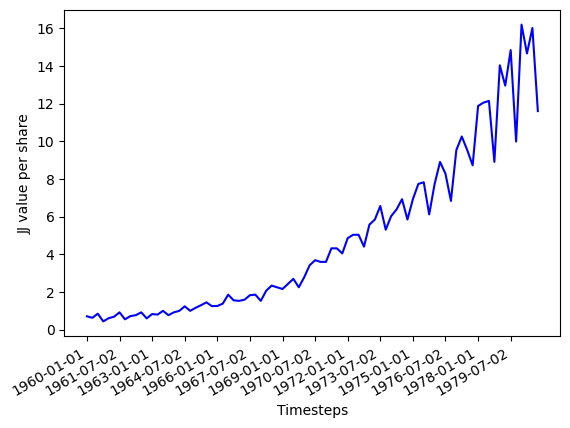

In [7]:
fig, ax = plt.subplots()
ax.plot(series_jj, 'b-')
ax.set_xticks(series_jj.index[::6])
ax.set_xlabel('Timesteps')
ax.set_ylabel('JJ value per share')
fig.autofmt_xdate()
plt.show()

In [8]:
decomposition = STL(series_jj, period=12).fit()

In [9]:
type(decomposition)

statsmodels.tsa.seasonal.DecomposeResult

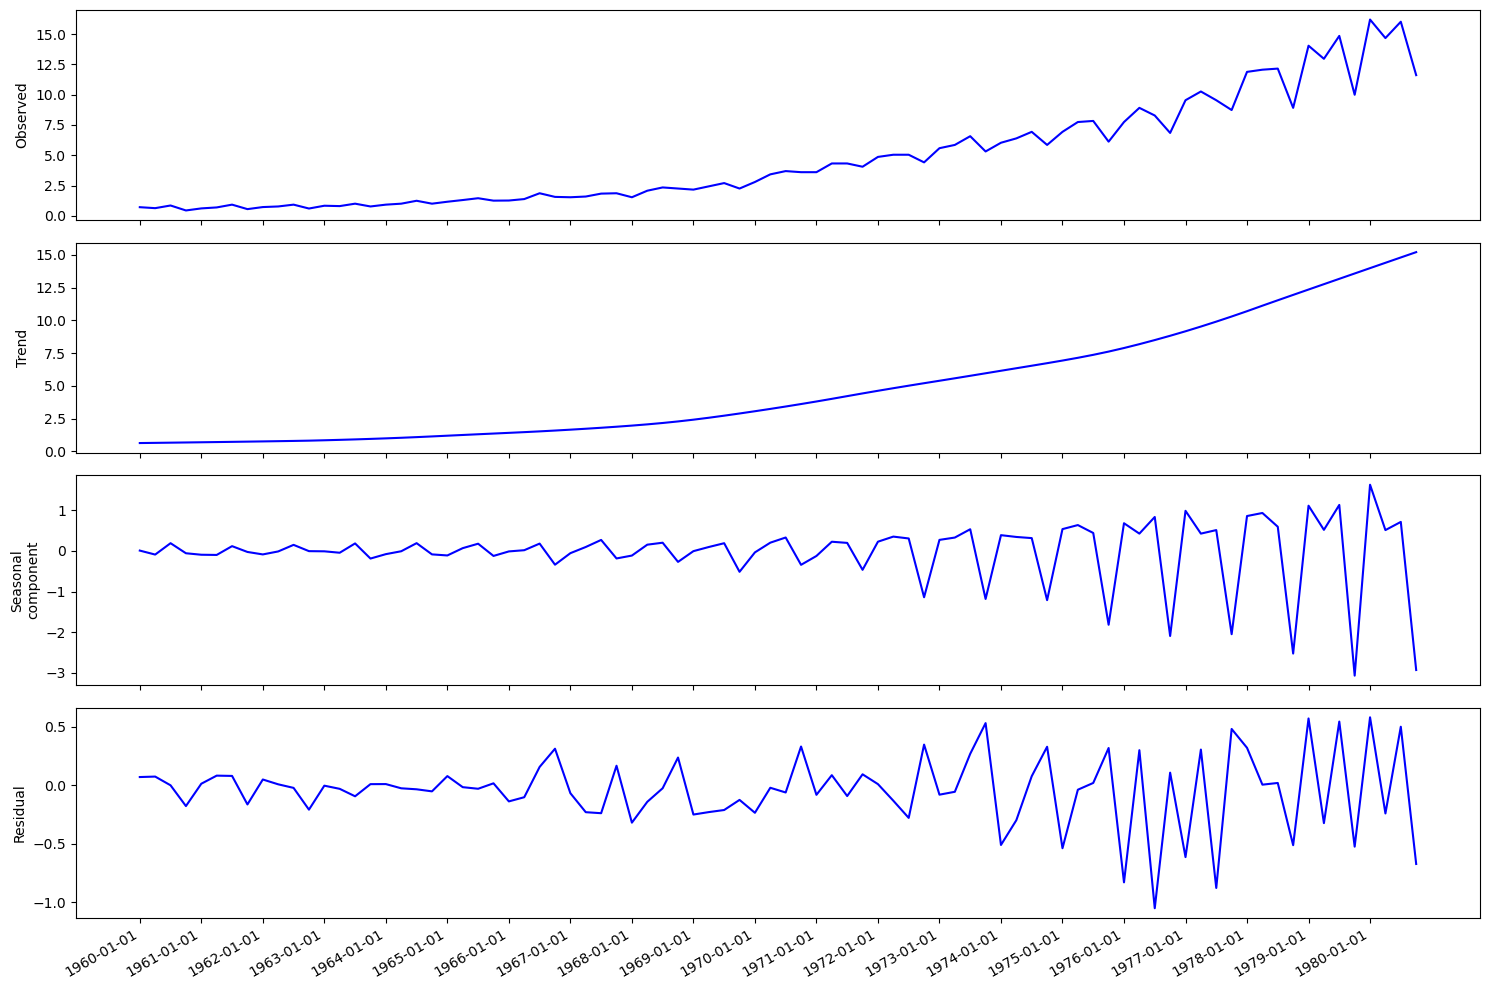

In [10]:
fig, ax = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(15, 10))
ax[0].plot(decomposition.observed, 'b-')
ax[0].set_ylabel('Observed')

ax[1].plot(decomposition.trend, 'b-')
ax[1].set_ylabel('Trend')

ax[2].plot(decomposition.seasonal, 'b-')
ax[2].set_ylabel('Seasonal\ncomponent')

ax[3].plot(decomposition.resid, 'b-')
ax[3].set_ylabel('Residual')

ax[3].set_xticks(series_jj.index[::4])
fig.autofmt_xdate()
fig.tight_layout()

## Integration order

In [11]:
adfuller(series_jj)

(np.float64(2.742016573457479),
 1.0,
 11,
 72,
 {'1%': np.float64(-3.524624466842421),
  '5%': np.float64(-2.9026070739026064),
  '10%': np.float64(-2.5886785262345677)},
 np.float64(82.63760283301104))

In [12]:
def diff(x, d, lag = 1):
    series = list(x)
    for _ in range(d):
        series = np.diff(series, n=lag)
    return series

In [13]:
p_value = []
integration_order = list(product(
    [0, 1, 2], [1], [0, 1, 2], [4]
))
for order in integration_order:
    series = diff(series_jj, d=order[0], lag=order[1])
    series = diff(series, d=order[2], lag=order[3])
    p_value.append([*order, adfuller(series)[1]])
df_p_value = pd.DataFrame(p_value, columns=['d', 'lag', 'D', 'm', 'p-value'])

In [14]:
df_p_value

,d,lag,D,m,p-value
0,0,1,0,4,1.000000e+00
1,0,1,1,4,7.923916e-07
2,0,1,2,4,3.593625e-15
3,1,1,0,4,9.088542e-01
4,1,1,1,4,1.407057e-07
5,1,1,2,4,1.833636e-20
6,2,1,0,4,6.051100e-03
7,2,1,1,4,7.114670e-09
8,2,1,2,4,3.244753e-23


In [15]:
order_list = list(product(
    np.arange(0, 4, 1), [0, 1], np.arange(0, 4, 1),
    np.arange(0, 4, 1), [1], np.arange(0, 4, 1)
))

In [16]:
order_list[:4]

[(np.int64(0), 0, np.int64(0), np.int64(0), 1, np.int64(0)),
 (np.int64(0), 0, np.int64(0), np.int64(0), 1, np.int64(1)),
 (np.int64(0), 0, np.int64(0), np.int64(0), 1, np.int64(2)),
 (np.int64(0), 0, np.int64(0), np.int64(0), 1, np.int64(3))]

In [17]:
len(order_list)

512

In [18]:
train = series_jj[:-4]
test = series_jj[-4:]

In [19]:
def optimize_sarima(series: Union[list, pd.Series], order_list: list, s: int) -> pd.DataFrame:
    """
    Choose the p, q, P, Q parameters in the SARIMA model.

    Params:
    -------
    series: Union[list, pd.Series]
        time series 
    order_list: list
        a list with all options of p, d, q, P, D,  Q
    s: int
        seasonal frequency (size of seasonal period)

    Returns:
    -------
        a dataframe with eight columns: p, d, q, P, D, Q, m, AIC
    """

    results = []
    for order in tqdm(order_list):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = SARIMAX(
                    series, order = order[:3], seasonal_order=(*order[3:], s)
                ).fit(disp=False)
                results.append([*order, s, model.aic])
        except:
            continue
        

    return pd.DataFrame(
        results,
        columns=['p', 'd', 'q', 'P', 'D', 'Q', 'm', 'AIC']
    ).sort_values(by='AIC', ascending=True).reset_index(drop=True)

## Selecting the model with lowest AIC

In [22]:
df_aic = optimize_sarima(train, order_list, 4)

  0%|          | 0/512 [00:00<?, ?it/s]

In [24]:
df_aic.head()

,p,d,q,P,D,Q,m,AIC
0,3,1,0,2,1,1,4,88.830738
1,1,1,2,0,1,0,4,89.609996
2,3,1,1,0,1,0,4,89.677549
3,1,1,3,0,1,0,4,89.734026
4,3,1,3,1,1,1,4,89.780985


## Residuals

In [35]:
model = SARIMAX(
    train, order=(3, 1, 0), seasonal_order=(2, 1, 1, 4)
).fit(disp=False)

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [36]:
print(model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                data   No. Observations:                   80
Model:             SARIMAX(3, 1, 0)x(2, 1, [1], 4)   Log Likelihood                 -37.415
Date:                             Sun, 03 May 2026   AIC                             88.831
Time:                                     10:46:06   BIC                            105.053
Sample:                                          0   HQIC                            95.308
                                              - 80                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8213      0.114     -7.188      0.000      -1.045      -0.597
ar.L2         -0.3659      

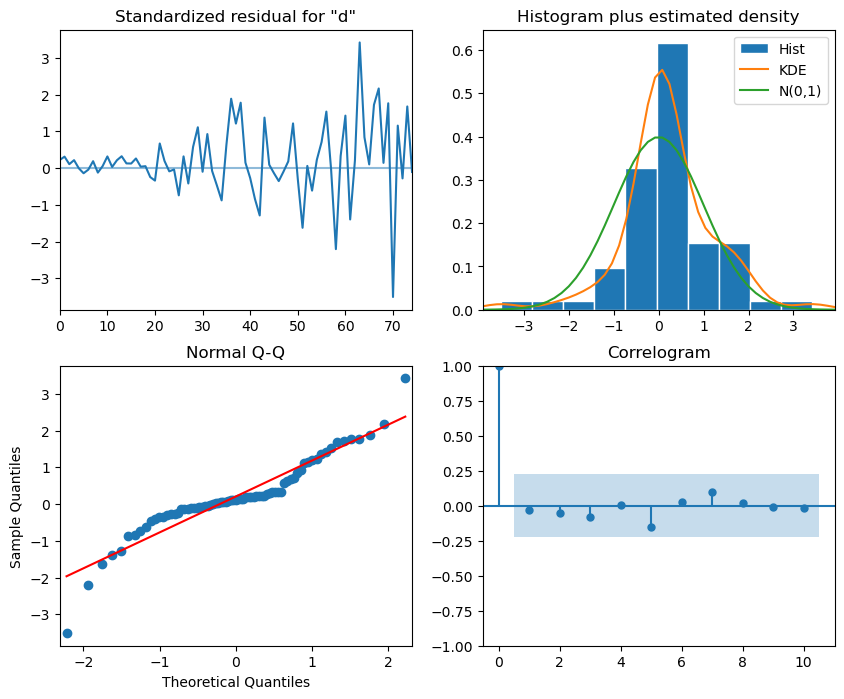

In [37]:
model.plot_diagnostics(figsize=(10, 8));

In [38]:
residuals = model.resid

In [40]:
acorr_ljungbox(residuals)

,lb_stat,lb_pvalue
1,0.083678,0.772374
2,0.248750,0.883049
3,1.099846,0.777111
4,1.120919,0.890939
5,2.852335,0.722739
6,2.942980,0.815969
7,3.803307,0.802133
8,3.857054,0.869785
9,3.863387,0.920172
10,3.886099,0.952339


In [42]:
kstest_normal(residuals)

(np.float64(0.15329376092527913), np.float64(0.0009999999999998899))

## Prediction

In [45]:
test

date
1980-01-01    16.20
1980-04-01    14.67
1980-07-02    16.02
1980-10-01    11.61
Name: data, dtype: float64

In [50]:
df_pred = pd.DataFrame({
    'observed': test.values,
    'seasonal': train.iloc[-4:].values,
    'sarima': model.get_prediction(0, train.shape[0] + 4 -1).predicted_mean[-4:]
})

/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/gilberto/anaconda3/envs/timeseries/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [52]:
df_pred.index = test.index.copy()

In [53]:
df_pred

,observed,seasonal,sarima
date,,,
1980-01-01,16.20,14.04,16.533092
1980-04-01,14.67,12.96,14.093910
1980-07-02,16.02,14.85,17.287541
1980-10-01,11.61,9.99,11.380451


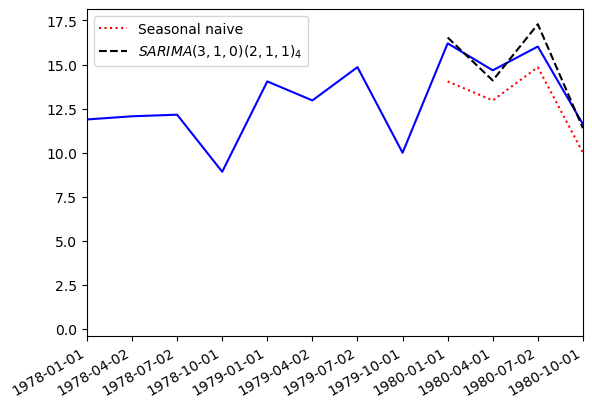

In [71]:
fig, ax = plt.subplots()
ax.plot(series_jj, 'b-')
ax.plot(df_pred['seasonal'], 'r:', label='Seasonal naive')
ax.plot(df_pred['sarima'], 'k--', label='$SARIMA(3, 1, 0)(2, 1, 1)_4$')
ax.set_xlim([series_jj.index[-12], series_jj.index[-1]])
ax.legend()
fig.autofmt_xdate()
plt.show()

In [72]:
mape = lambda y, p: np.mean(100 * np.abs(y-p) / np.abs(y))

In [73]:
mape_series = pd.Series({
    'seasonal': mape(df_pred['observed'], df_pred['seasonal']),
    'sarima': mape(df_pred['observed'], df_pred['sarima'])
})

In [74]:
mape_series

seasonal    11.561659
sarima       3.968132
dtype: float64

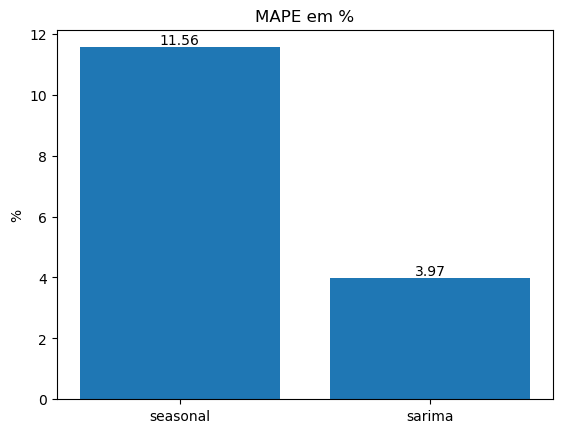

In [75]:
fig, ax = plt.subplots()
bars = ax.bar(mape_series.index, mape_series.values)
ax.bar_label(bars, fmt='%.2f')
ax.set_ylabel('%')
ax.set_title('MAPE em %')
plt.show()